<a href="https://colab.research.google.com/github/woranun-00/-1/blob/main/Module-A-Notebooks/SC612104_Session10_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 612 104 Essential Data Science
## Data Cleaning: Missing Values, Outliers, และ Data Transformation

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### เนื้อหาใน Notebook นี้

**ส่วนที่ 1: Missing Values (ค่าขาดหาย)**
1. ตรวจหา Missing Values (`isnull()`, Heatmap)
2. กลยุทธ์จัดการ Missing Values: Drop / Fill (mean, median, mode, forward fill) พร้อมเหตุผลการเลือก

**ส่วนที่ 2: Outliers (ค่าผิดปกติ)**/
3. ตรวจหา Outliers ด้วย Boxplot/
4. IQR Method/
5. Z-score Method/
6. การตัดสินใจ: Keep / Remove / Cap

**ส่วนที่ 3: Data Transformation**/
7. Normalization (Min-Max Scaling)/
8. Standardization (Z-score Scaling)/
9. Encoding Categorical Data (Label Encoding, One-Hot Encoding)/
10. สร้าง New Feature อย่างง่าย (Feature Engineering เบื้องต้น)

**แบบฝึกหัดท้ายเรื่อง**

> 📁 **ไฟล์ที่ต้องใช้ในคาบนี้:** `world_weather_sample.csv` (ไฟล์เดิมจาก Session 8-9) — ไฟล์นี้**จงใจมี** missing values, outliers, แถวซ้ำ, และตัวพิมพ์ไม่สม่ำเสมออยู่แล้ว ทำให้เหมาะมากสำหรับฝึก data cleaning แบบเจอปัญหาจริง

> ⚠️ **ข้อคิดสำคัญก่อนเริ่ม:** การทำความสะอาดข้อมูล**ไม่มีสูตรสำเร็จตายตัว** — ทุกการตัดสินใจ (จะ drop หรือ fill, จะ remove หรือ cap outlier) ต้องมี**เหตุผลรองรับ**เสมอ ขึ้นอยู่กับบริบทของข้อมูลและสิ่งที่จะนำไปวิเคราะห์ต่อ Notebook นี้จะเน้นทั้ง "วิธีทำ" และ "เหตุผลในการเลือกวิธี" ควบคู่กันไปตลอด


In [3]:
# # ถ้าใช้ Google Colab และยังไม่ได้อัปโหลดไฟล์ ให้รันเซลล์นี้เพื่ออัปโหลด world_weather_sample.csv
# try:
#     from google.colab import files
#     uploaded = files.upload()
# except ImportError:
#     print("ไม่ได้รันบน Colab - ข้ามขั้นตอนนี้ (ตรวจสอบว่าไฟล์ CSV อยู่ในโฟลเดอร์เดียวกับ Notebook นี้)")

In [11]:
import pandas as pd
import numpy as np
import matplotlib, os, shutil
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-thai-tlwg is already the newest version (1:0.7.3-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!


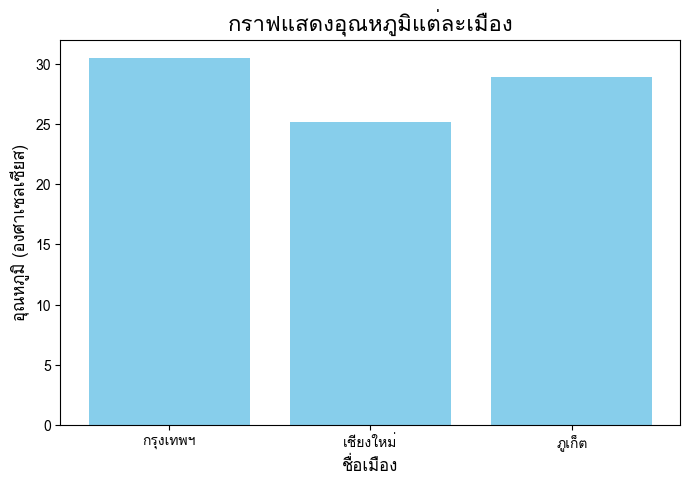

In [12]:
# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [5]:
df = pd.read_csv("https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/world_weather_sample.csv")
df["date"] = pd.to_datetime(df["date"])
print("โหลดข้อมูลสำเร็จ! ขนาด:", df.shape)
df

โหลดข้อมูลสำเร็จ! ขนาด: (2075, 10)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1
...,...,...,...,...,...,...,...,...,...,...
2070,1093,2025-01-13,Mexico City,Mexico,North America,17.8,63.3,7.4,10.5,1001.2
2071,1769,2025-02-28,Nairobi,Kenya,Africa,20.6,65.8,3.7,13.3,1015.6
2072,1738,2025-01-28,Nairobi,Kenya,Africa,21.7,51.0,9.5,27.2,1013.9
2073,1210,2025-02-09,Toronto,Canada,North America,NaN,65.0,9.1,6.9,1007.8


---
# ส่วนที่ 1: Missing Values (ค่าขาดหาย)

## ทำไมต้องทำความสะอาดข้อมูลก่อน?

ข้อมูลจริงแทบทุกชุด**ไม่สมบูรณ์**ตั้งแต่แรก — เซ็นเซอร์เสีย, คนกรอกข้อมูลพลาด, ระบบส่งข้อมูลขาดหาย ฯลฯ ถ้านำข้อมูลที่ไม่สะอาดไปวิเคราะห์หรือสร้างโมเดลตรงๆ จะได้ผลลัพธ์ที่**ผิดเพี้ยน**โดยไม่รู้ตัว

ตัวอย่างที่เคยเห็นมาแล้วจาก Session 8: `describe()` ของ `temperature_c` มีค่า `std` สูงผิดปกติ เพราะมีค่า `999.0` และ `-88.0` ปนอยู่ — นี่คือผลกระทบของข้อมูลไม่สะอาดที่ส่งต่อไปยังการคำนวณทุกอย่างถัดจากนั้น

**ขั้นตอนการทำความสะอาดข้อมูล (Data Cleaning) โดยทั่วไป:**
1. ตรวจหา Missing Values → ตัดสินใจ drop/fill
2. ตรวจหา Outliers → ตัดสินใจ keep/remove/cap
3. แปลงข้อมูลให้พร้อมใช้งาน (Transformation/Encoding)


---
## 1. ตรวจหา Missing Values

### 1.1 `isnull()` / `isna()` — เช็คทีละค่า

`.isnull()` และ `.isna()` ทำงานเหมือนกันทุกอย่าง (เป็นชื่อเรียกคนละชื่อของฟังก์ชันเดียวกัน) คืนค่า `True`/`False` ว่าแต่ละช่องเป็นค่าขาดหายหรือไม่


In [15]:
# เช็คทีละค่า (ได้ DataFrame ของ True/False ขนาดเท่าต้นฉบับ)
df.isnull().sum()

,0
record_id,0
date,0
city,0
country,0
region,0
temperature_c,20
humidity_pct,82
rainfall_mm,62
wind_speed_kmh,41
pressure_hpa,32


In [17]:
print(df.isnull().head())

   record_id   date   city  country  region  temperature_c  humidity_pct  \
0      False  False  False    False   False          False         False   
1      False  False  False    False   False          False         False   
2      False  False  False    False   False          False         False   
3      False  False  False    False   False          False         False   
4      False  False  False    False   False          False         False   

   rainfall_mm  wind_speed_kmh  pressure_hpa  
0        False           False         False  
1        False           False         False  
2        False           False         False  
3        False           False         False  
4        False           False         False  


### 1.2 นับจำนวน Missing Values ต่อคอลัมน์ (เทคนิคที่ใช้บ่อยที่สุด)

รวม `.isnull()` กับ `.sum()` (เชื่อมกับที่เรียนมา: `True` นับเป็น 1, `False` นับเป็น 0)


In [18]:
missing_count = df.isnull().sum()
print("จำนวน missing values ต่อคอลัมน์:")
print(missing_count)

print("\nคิดเป็นเปอร์เซ็นต์:")
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct.round(2))

จำนวน missing values ต่อคอลัมน์:
record_id          0
date               0
city               0
country            0
region             0
temperature_c     20
humidity_pct      82
rainfall_mm       62
wind_speed_kmh    41
pressure_hpa      32
dtype: int64

คิดเป็นเปอร์เซ็นต์:
record_id         0.00
date              0.00
city              0.00
country           0.00
region            0.00
temperature_c     0.96
humidity_pct      3.95
rainfall_mm       2.99
wind_speed_kmh    1.98
pressure_hpa      1.54
dtype: float64


### 1.3 สรุป Missing Values แบบตารางเดียว (เทคนิคที่ใช้ในงานจริง)


In [19]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().sum() / len(df) * 100).round(2),
})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]   # โชว์แค่คอลัมน์ที่มี missing
missing_summary = missing_summary.sort_values("missing_count", ascending=False)
print(missing_summary)

                missing_count  missing_pct
humidity_pct               82         3.95
rainfall_mm                62         2.99
wind_speed_kmh             41         1.98
pressure_hpa               32         1.54
temperature_c              20         0.96


### 1.4 Heatmap — มองเห็น Missing Values แบบภาพรวม

ตัวเลขบอกว่า "มีกี่ค่า" แต่ **heatmap** ช่วยให้เห็น "รูปแบบ" ของ missing values — เช่น ขาดหายแบบสุ่ม หรือขาดหายเป็นช่วงๆ ติดกัน (ซึ่งอาจบอกใบ้ถึงสาเหตุ เช่น เซ็นเซอร์เสียติดต่อกันหลายวัน)


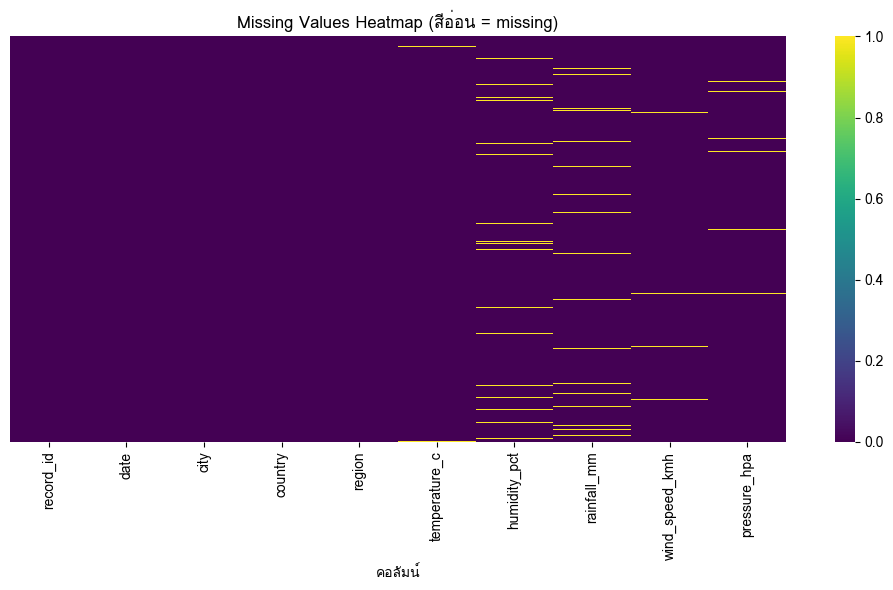

In [20]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=True, cmap="viridis", yticklabels=False)
plt.title("Missing Values Heatmap (สีอ่อน = missing)")
plt.xlabel("คอลัมน์")
plt.tight_layout()
plt.show()

**อ่าน heatmap อย่างไร:** แต่ละแถวคือ 1 record ของข้อมูล แต่ละคอลัมน์คือ 1 คอลัมน์ของ DataFrame — แถบสีอ่อน (ตาม colormap ที่กำหนด) คือตำแหน่งที่เป็น missing value ถ้าเห็นแถบสีอ่อนกระจายทั่วๆแบบสุ่ม มักหมายถึงปัญหาเกิดแบบสุ่ม (เช่น sensor error เป็นครั้งๆ) แต่ถ้าเห็นเป็นแถบยาวต่อกัน อาจหมายถึงปัญหาเชิงระบบ (เช่น เซ็นเซอร์พังต่อเนื่องหลายวัน)

### 1.5 Heatmap แบบสรุปเฉพาะคอลัมน์ตัวเลข (อ่านง่ายกว่าเมื่อมีหลายคอลัมน์)


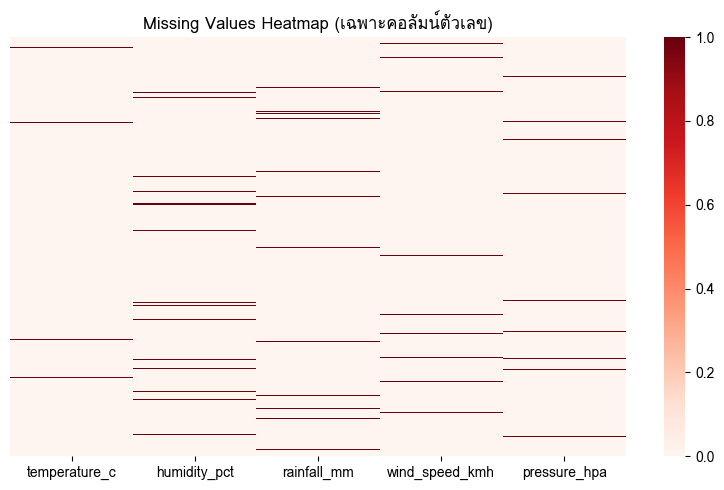

In [21]:
numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]

plt.figure(figsize=(8, 5))
sns.heatmap(df[numeric_cols].isnull(), cbar=True, cmap="Reds", yticklabels=False)
plt.title("Missing Values Heatmap (เฉพาะคอลัมน์ตัวเลข)")
plt.tight_layout()
plt.show()

### 1.6 ตรวจสอบ Missing Values แยกตามกลุ่ม (เชื่อมกับ `groupby()` ที่เรียนมา)

บางครั้ง missing values ไม่ได้กระจายเท่ากันทุกกลุ่ม — ลองเช็คว่าแต่ละเมืองมี missing values ต่างกันไหม (อาจบอกใบ้ว่าเมืองไหนมีปัญหาเซ็นเซอร์มากกว่าเมืองอื่น)


In [22]:
missing_by_city = df.groupby("city")[numeric_cols].apply(lambda x: x.isnull().sum())
print(missing_by_city.sum(axis=1).sort_values(ascending=False).head(10))

city
Auckland       14
Lagos          14
Bangkok        13
London         13
Tokyo          12
Los Angeles    11
Nairobi        11
New York       11
Mexico City    10
Cape Town      10
dtype: int64


---
## 2. กลยุทธ์จัดการ Missing Values

ไม่มีวิธีใดที่ "ถูกที่สุด" ตลอดเวลา — ต้องเลือกตามบริบท คาบนี้จะแนะนำ 5 กลยุทธ์หลัก พร้อม**เหตุผล**ว่าควรเลือกใช้ตอนไหน

| กลยุทธ์ | ทำอะไร | ควรใช้เมื่อ... | ข้อเสีย |
|---|---|---|---|
| **Drop rows** | ลบทั้งแถวที่มี missing | missing มีน้อยมาก (<5%) และข้อมูลมีพอเหลือใช้ | เสียข้อมูลที่อาจมีประโยชน์ในคอลัมน์อื่น |
| **Drop columns** | ลบทั้งคอลัมน์ที่มี missing | คอลัมน์นั้น missing มากเกินไป (>50%) หรือไม่สำคัญ | เสียข้อมูลทั้งคอลัมน์ไปเลย |
| **Fill ด้วย Mean** | แทนด้วยค่าเฉลี่ย | ข้อมูลตัวเลข กระจายแบบสมมาตร ไม่มี outlier มาก | Mean ถูกดึงค่าได้ง่ายถ้ามี outlier |
| **Fill ด้วย Median** | แทนด้วยค่ามัธยฐาน | ข้อมูลตัวเลข มี outlier หรือกระจายไม่สมมาตร (skewed) | ไม่สะท้อนค่าเฉลี่ยจริงถ้าข้อมูลสมมาตรมาก |
| **Fill ด้วย Mode** | แทนด้วยค่าที่พบบ่อยสุด | ข้อมูลเชิงหมวดหมู่ (categorical) | ถ้าหลายค่ามีความถี่เท่ากัน อาจเลือกไม่ตรงใจ |
| **Forward Fill** | แทนด้วยค่าก่อนหน้า | ข้อมูล time series ที่ค่าต่อเนื่องกันได้ (เช่น อุณหภูมิวันถัดไปใกล้เคียงวันก่อน) | ใช้ไม่ได้ถ้าข้อมูลไม่มีลำดับเวลาที่มีความหมาย |

### 2.1 Drop Rows — ลบทั้งแถวที่มี missing


In [23]:
print("ขนาดข้อมูลก่อน drop:", df.shape)

# dropna() ลบทุกแถวที่มี missing อย่างน้อย 1 คอลัมน์ (default)
df_dropped = df.dropna()
print("ขนาดข้อมูลหลัง dropna() (ลบถ้ามี missing ที่คอลัมน์ใดก็ได้):", df_dropped.shape)

# ระบุเฉพาะบางคอลัมน์ที่ถ้า missing แล้วถึงจะลบแถวนั้น
df_dropped_subset = df.dropna(subset=["temperature_c"])
print("ขนาดข้อมูลหลัง dropna(subset=['temperature_c']):", df_dropped_subset.shape)

print(f"\nเหตุผล: เนื่องจาก missing values ในแต่ละคอลัมน์มีไม่เกิน {df.isnull().sum().max()} แถว "
      f"จาก {len(df)} แถว (~{(df.isnull().sum().max()/len(df)*100):.1f}%) "
      f"การ drop ทั้งแถวที่ missing ในคอลัมน์เดียว อาจเสียข้อมูลคอลัมน์อื่นที่สมบูรณ์ดีไปด้วย "
      f"ในกรณีนี้ การ fill มักเหมาะกว่าการ drop")

ขนาดข้อมูลก่อน drop: (2075, 10)
ขนาดข้อมูลหลัง dropna() (ลบถ้ามี missing ที่คอลัมน์ใดก็ได้): (1846, 10)
ขนาดข้อมูลหลัง dropna(subset=['temperature_c']): (2055, 10)

เหตุผล: เนื่องจาก missing values ในแต่ละคอลัมน์มีไม่เกิน 82 แถว จาก 2075 แถว (~4.0%) การ drop ทั้งแถวที่ missing ในคอลัมน์เดียว อาจเสียข้อมูลคอลัมน์อื่นที่สมบูรณ์ดีไปด้วย ในกรณีนี้ การ fill มักเหมาะกว่าการ drop


### 2.2 Drop Columns — ลบทั้งคอลัมน์ (เมื่อ missing มากเกินไป)


In [24]:
# ตัวอย่าง (สมมติ): ถ้ามีคอลัมน์ที่ missing เกิน 50% ควรพิจารณาลบทั้งคอลัมน์
threshold_pct = 50
cols_to_check = df.isnull().sum() / len(df) * 100
cols_too_much_missing = cols_to_check[cols_to_check > threshold_pct].index.tolist()

print(f"คอลัมน์ที่ missing เกิน {threshold_pct}%:", cols_too_much_missing)
print("(ในข้อมูลนี้ไม่มีคอลัมน์ไหน missing เกินเกณฑ์นี้ — ทุกคอลัมน์ missing ไม่เกิน 4% จึงไม่ควร drop ทั้งคอลัมน์)")

# ถ้ามีคอลัมน์ที่เข้าเกณฑ์ จะลบด้วย:
# df_dropped_cols = df.drop(columns=cols_too_much_missing)

คอลัมน์ที่ missing เกิน 50%: []
(ในข้อมูลนี้ไม่มีคอลัมน์ไหน missing เกินเกณฑ์นี้ — ทุกคอลัมน์ missing ไม่เกิน 4% จึงไม่ควร drop ทั้งคอลัมน์)


### 2.3 Fill ด้วย Mean (ค่าเฉลี่ย)

เหมาะกับข้อมูลตัวเลขที่กระจายตัวค่อนข้างสมมาตร **แต่ต้องระวัง:** ถ้าคอลัมน์นั้นมี outliers (อย่างที่รู้ว่า `temperature_c` มี 999.0 ปนอยู่) mean จะถูกดึงค่าผิดเพี้ยนไปด้วย — ต้องจัดการ outliers ก่อน หรือเลือกใช้ median แทน


In [25]:
# ตัวอย่าง fill ด้วย mean - ใช้กับ pressure_hpa เพราะกระจายตัวสมมาตร ไม่มี outlier ที่รู้จัก
df_filled = df.copy()   # ทำงานกับ copy เสมอ ไม่ทับ df ต้นฉบับโดยไม่ตั้งใจ

pressure_mean = df_filled["pressure_hpa"].mean()
print(f"ค่าเฉลี่ย pressure_hpa: {pressure_mean:.2f}")

df_filled["pressure_hpa"] = df_filled["pressure_hpa"].fillna(pressure_mean)
print(f"จำนวน missing ใน pressure_hpa หลัง fill: {df_filled['pressure_hpa'].isnull().sum()}")

print(f"\nเหตุผล: pressure_hpa ไม่มี outlier ที่รู้จัก (ไม่ได้ถูกจงใจใส่ค่าผิดปกติ) "
      f"และข้อมูลความกดอากาศมักกระจายตัวสมมาตรตามธรรมชาติ จึงใช้ mean ได้อย่างเหมาะสม")

ค่าเฉลี่ย pressure_hpa: 1013.13
จำนวน missing ใน pressure_hpa หลัง fill: 0

เหตุผล: pressure_hpa ไม่มี outlier ที่รู้จัก (ไม่ได้ถูกจงใจใส่ค่าผิดปกติ) และข้อมูลความกดอากาศมักกระจายตัวสมมาตรตามธรรมชาติ จึงใช้ mean ได้อย่างเหมาะสม


### 2.4 Fill ด้วย Median (ค่ามัธยฐาน)

เหมาะกับคอลัมน์ที่**มี outliers** หรือกระจายตัวไม่สมมาตร (skewed) เพราะ median ไม่ถูกดึงค่าง่ายเท่า mean


In [26]:
# temperature_c มี outliers (999, -88) -- median ทนทานต่อ outlier มากกว่า mean
temp_mean = df_filled["temperature_c"].mean()
temp_median = df_filled["temperature_c"].median()
print(f"ค่าเฉลี่ย (mean) ของ temperature_c: {temp_mean:.2f}   <- ถูกดึงค่าจาก outlier ให้สูงผิดปกติ")
print(f"ค่ามัธยฐาน (median) ของ temperature_c: {temp_median:.2f}   <- ใกล้เคียงความเป็นจริงมากกว่า")

df_filled["temperature_c"] = df_filled["temperature_c"].fillna(temp_median)
print(f"\nจำนวน missing ใน temperature_c หลัง fill: {df_filled['temperature_c'].isnull().sum()}")

print(f"\nเหตุผล: temperature_c มี outliers ที่รุนแรง (999, -88) ทำให้ mean เพี้ยนไปมาก "
      f"median ทนทานต่อค่าผิดปกติแบบนี้ จึงเป็นตัวแทนที่เหมาะสมกว่าในการ fill missing values")

ค่าเฉลี่ย (mean) ของ temperature_c: 21.84   <- ถูกดึงค่าจาก outlier ให้สูงผิดปกติ
ค่ามัธยฐาน (median) ของ temperature_c: 20.00   <- ใกล้เคียงความเป็นจริงมากกว่า

จำนวน missing ใน temperature_c หลัง fill: 0

เหตุผล: temperature_c มี outliers ที่รุนแรง (999, -88) ทำให้ mean เพี้ยนไปมาก median ทนทานต่อค่าผิดปกติแบบนี้ จึงเป็นตัวแทนที่เหมาะสมกว่าในการ fill missing values


### 2.5 Fill ด้วย Mode (ค่าที่พบบ่อยที่สุด) — สำหรับข้อมูลเชิงหมวดหมู่

ใช้กับคอลัมน์ที่เป็น category/text เพราะ mean/median ใช้กับ text ไม่ได้


In [27]:
# จำลองสถานการณ์: ถ้า region มี missing บางแถว (ในข้อมูลจริงไม่มี แต่สมมติเพื่อสอน)
df_demo = df_filled.copy()
demo_idx = df_demo.sample(20, random_state=1).index
df_demo.loc[demo_idx, "region"] = np.nan

print("จำนวน missing ใน region (จำลอง):", df_demo["region"].isnull().sum())

region_mode = df_demo["region"].mode()[0]   # .mode() คืน Series อาจมีหลายค่า เอาตัวแรก
print(f"ค่าที่พบบ่อยที่สุดของ region: {region_mode}")

df_demo["region"] = df_demo["region"].fillna(region_mode)
print("จำนวน missing ใน region หลัง fill:", df_demo["region"].isnull().sum())

print(f"\nเหตุผล: region เป็นข้อมูลเชิงหมวดหมู่ (categorical) คำนวณ mean/median ไม่ได้ "
      f"การแทนด้วยค่าที่พบบ่อยที่สุด (mode) เป็นวิธีมาตรฐานสำหรับข้อมูลประเภทนี้ "
      f"แต่ควรระวัง: ถ้า missing เยอะ การ fill ด้วย mode ซ้ำๆ อาจทำให้สัดส่วนของกลุ่มนั้นสูงเกินจริง")

จำนวน missing ใน region (จำลอง): 20
ค่าที่พบบ่อยที่สุดของ region: Asia
จำนวน missing ใน region หลัง fill: 0

เหตุผล: region เป็นข้อมูลเชิงหมวดหมู่ (categorical) คำนวณ mean/median ไม่ได้ การแทนด้วยค่าที่พบบ่อยที่สุด (mode) เป็นวิธีมาตรฐานสำหรับข้อมูลประเภทนี้ แต่ควรระวัง: ถ้า missing เยอะ การ fill ด้วย mode ซ้ำๆ อาจทำให้สัดส่วนของกลุ่มนั้นสูงเกินจริง


### 2.6 Forward Fill — แทนด้วยค่าก่อนหน้า (เหมาะกับ time series)

ใช้เมื่อข้อมูลมี**ลำดับเวลาที่มีความหมาย** และค่าที่ขาดหายน่าจะใกล้เคียงกับค่าก่อนหน้า (เช่น อุณหภูมิของเมืองเดียวกันในวันติดกัน)

**ข้อสำคัญ:** ต้อง**เรียงข้อมูลตามเวลาก่อน** และควรทำแยกตามกลุ่ม (เช่น แยกตามเมือง) ไม่อย่างนั้นจะดึงค่าจากเมืองอื่นมาใส่ผิดๆ


In [28]:
# ตัวอย่าง: forward fill อุณหภูมิ แยกตามเมือง (สำคัญมาก! ต้องแยกกลุ่มก่อน fill)
df_ffill = df.copy()
df_ffill = df_ffill.sort_values(["city", "date"])   # เรียงตามเมืองและวันที่ก่อนเสมอ

# ffill() ภายในแต่ละกลุ่มเมือง (ใช้ groupby + ffill ร่วมกัน)
df_ffill["temperature_c"] = df_ffill.groupby("city")["temperature_c"].ffill()

print("จำนวน missing ใน temperature_c ก่อน ffill:", df["temperature_c"].isnull().sum())
print("จำนวน missing ใน temperature_c หลัง ffill (แยกตามเมือง):", df_ffill["temperature_c"].isnull().sum())

print(f"\nเหตุผล: อุณหภูมิเป็นข้อมูล time series ที่มีความต่อเนื่อง (อุณหภูมิวันนี้ใกล้เคียงเมื่อวาน) "
      f"forward fill จึงสมเหตุสมผลกว่าการ fill ด้วยค่าเฉลี่ยรวมทั้งปี เพราะรักษาแนวโน้มตามฤดูกาลของแต่ละเมืองไว้ "
      f"**ข้อควรระวัง:** ถ้าแถวแรกของกลุ่มเป็น missing เลย ffill จะยังเหลือ NaN อยู่ (ไม่มีค่าก่อนหน้าให้ดึงมาใช้)")

จำนวน missing ใน temperature_c ก่อน ffill: 20
จำนวน missing ใน temperature_c หลัง ffill (แยกตามเมือง): 0

เหตุผล: อุณหภูมิเป็นข้อมูล time series ที่มีความต่อเนื่อง (อุณหภูมิวันนี้ใกล้เคียงเมื่อวาน) forward fill จึงสมเหตุสมผลกว่าการ fill ด้วยค่าเฉลี่ยรวมทั้งปี เพราะรักษาแนวโน้มตามฤดูกาลของแต่ละเมืองไว้ **ข้อควรระวัง:** ถ้าแถวแรกของกลุ่มเป็น missing เลย ffill จะยังเหลือ NaN อยู่ (ไม่มีค่าก่อนหน้าให้ดึงมาใช้)


> 💡 **เกร็ดเสริม:** มี `bfill()` (backward fill) ด้วย ทำงานตรงข้ามกับ `ffill()` คือดึงค่า**ถัดไป**มาแทน — ใช้เมื่อค่าก่อนหน้าไม่มี (เช่นแถวแรกของกลุ่ม) มักใช้คู่กัน: `ffill()` ก่อน แล้วตามด้วย `bfill()` เพื่อเก็บกรณีที่เหลือ

### 2.7 สรุป: เลือกกลยุทธ์อย่างไรให้เหมาะกับข้อมูลแต่ละคอลัมน์ในชุดนี้

| คอลัมน์ | Missing % | กลยุทธ์ที่แนะนำ | เหตุผล |
|---|---|---|---|
| `temperature_c` | ~1% | Median หรือ Forward fill (แยกตามเมือง) | มี outliers, เป็น time series ต่อเนื่อง |
| `humidity_pct` | ~4% | Median | มี outliers (150%), กระจายอาจไม่สมมาตร |
| `rainfall_mm` | ~3% | Median หรือ 0 | ฝนตกมักมีค่า 0 บ่อย (right-skewed) median เหมาะกว่า mean |
| `wind_speed_kmh` | ~2% | Median | มี outliers (ค่าติดลบ) |
| `pressure_hpa` | ~1.5% | Mean | กระจายสมมาตร ไม่มี outlier ที่รู้จัก |

**ข้อคิดสำคัญที่สุด:** ไม่มีกฎตายตัวว่า "ต้องใช้ median เสมอ" หรือ "ต้องใช้ mean เสมอ" — ต้องดูที่**การกระจายตัวของข้อมูลจริง**ในแต่ละคอลัมน์ (ลองดูด้วย `.describe()` หรือ histogram) ก่อนตัดสินใจทุกครั้ง


---
# ส่วนที่ 2: Outliers (ค่าผิดปกติ)

**Outlier** คือค่าที่ "แปลกแยก" จากข้อมูลส่วนใหญ่อย่างชัดเจน — อาจเกิดจาก:
- **ข้อผิดพลาดในการบันทึกข้อมูล** (เซ็นเซอร์เสีย, พิมพ์ผิด) เช่น `999.0`, `-88.0` ที่เจอในข้อมูลนี้
- **เหตุการณ์ที่เกิดขึ้นจริงแต่หาได้ยาก** (เช่น คลื่นความร้อนรุนแรงจริงๆ) — กรณีนี้ไม่ใช่ "ข้อผิดพลาด" แต่เป็นข้อมูลจริงที่ต้องตัดสินใจว่าจะเก็บไว้หรือไม่

**ความแตกต่างสำคัญ:** Missing values คือ "ไม่มีค่า" ส่วน Outlier คือ "มีค่า แต่ค่านั้นน่าสงสัย" — ต้องใช้วิธีตรวจหาคนละแบบ

## 3. ตรวจหา Outliers ด้วย Boxplot

**Boxplot** (แผนภาพกล่อง) แสดงการกระจายตัวของข้อมูลเป็นภาพ ทำให้เห็น outliers ได้ทันที


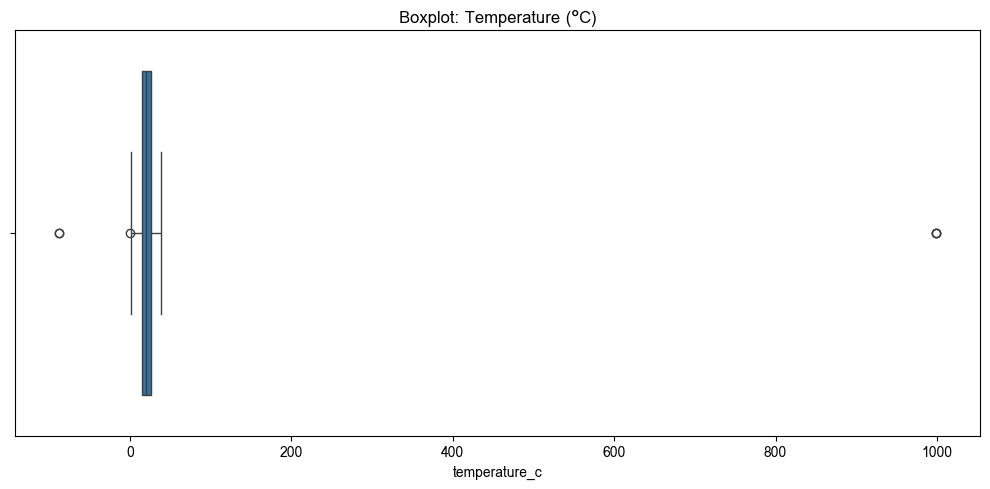

In [29]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="temperature_c")
plt.title("Boxplot: Temperature (°C)")
plt.tight_layout()
plt.show()

**อ่าน Boxplot อย่างไร:**
- **กล่อง (box)** → ครอบคลุมข้อมูล 50% กลาง (จาก Q1 ถึง Q3)
- **เส้นกลางกล่อง** → ค่ามัธยฐาน (median)
- **เส้นหนวด (whiskers)** → ขยายออกไปประมาณ 1.5×IQR จากกล่อง (รายละเอียดในหัวข้อถัดไป)
- **จุดเดี่ยวๆ ที่อยู่นอกหนวด** → **outliers** ที่ตรวจพบ

**🔍 สังเกต:** ควรเห็นจุดที่อยู่ไกลโพล่งออกไปทั้งสองด้าน (ใกล้ 999 และ -88) ซึ่งคือ outliers ที่เรารู้อยู่แล้วว่าถูกจงใจใส่ไว้ในข้อมูล

### 3.1 Boxplot แยกตามกลุ่ม (เชื่อมกับ `groupby()` ที่เรียนมา)

Boxplot แยกตามกลุ่มช่วยเปรียบเทียบการกระจายตัวระหว่างกลุ่มได้ในภาพเดียว


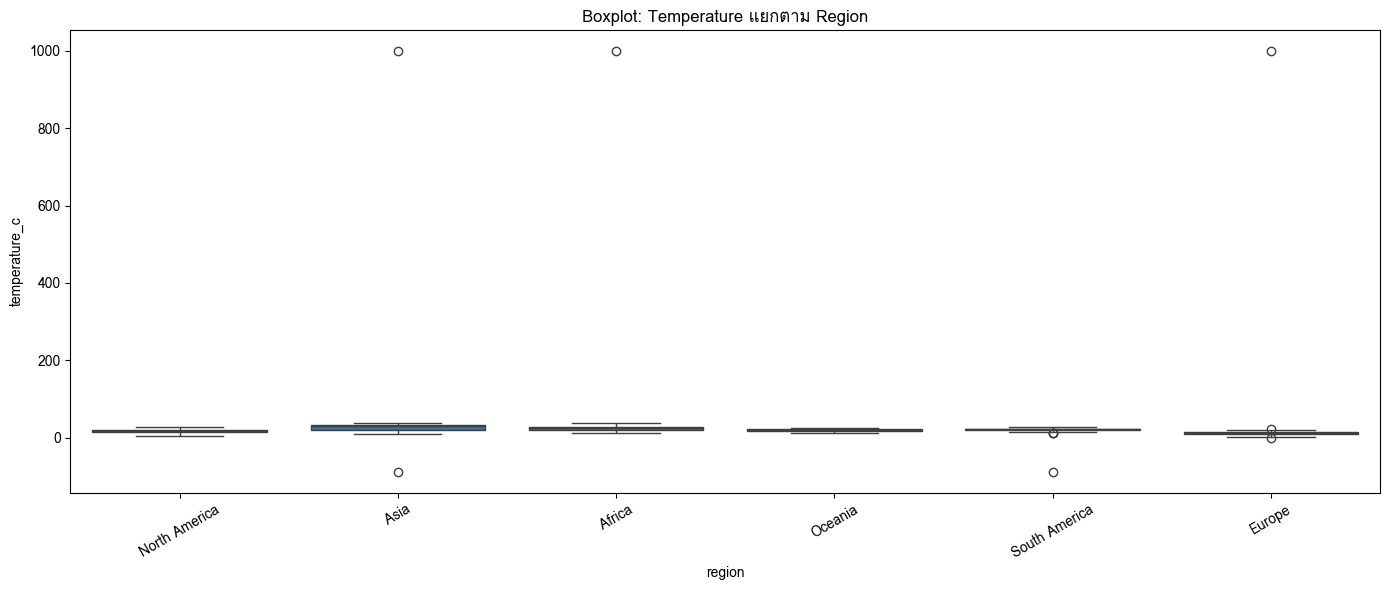

In [30]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="region", y="temperature_c")
plt.title("Boxplot: Temperature แยกตาม Region")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 3.2 Boxplot หลายคอลัมน์พร้อมกัน


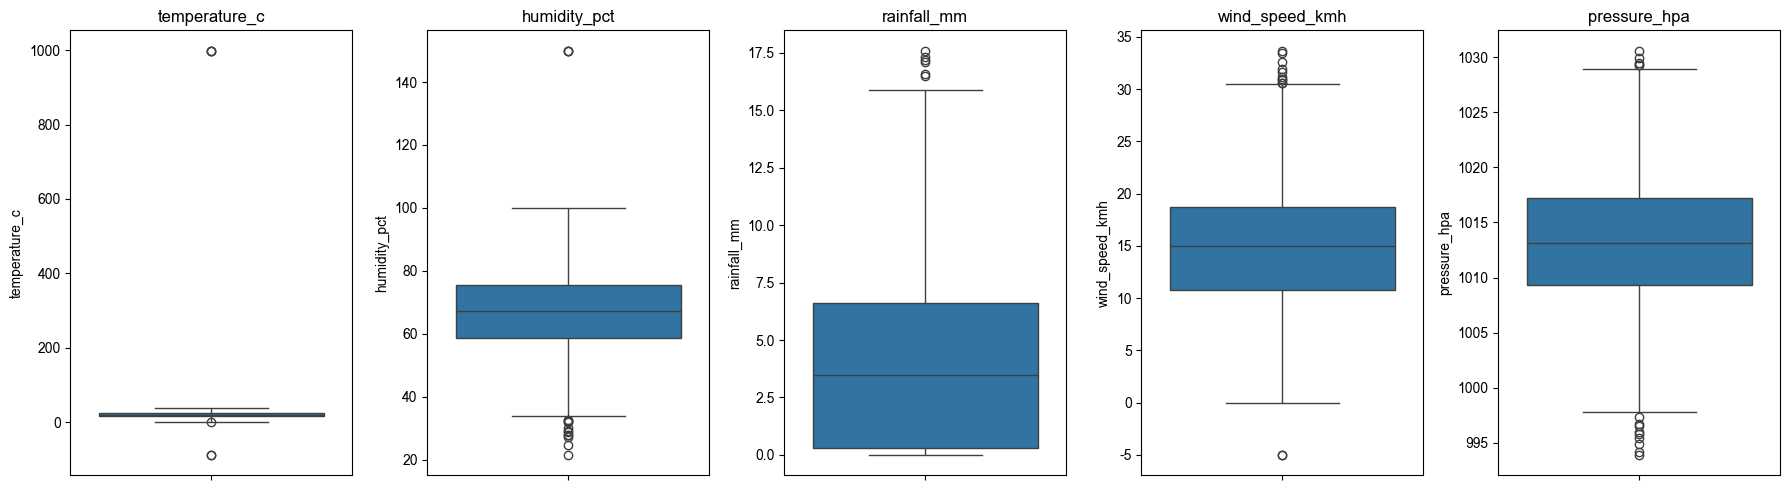

In [31]:
numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

**🔍 สังเกต:** `humidity_pct` ควรมีจุดผิดปกติเกิน 100% และ `wind_speed_kmh` ควรมีจุดที่ติดลบ — ทั้งสองเป็นไปไม่ได้ในความเป็นจริง (ความชื้นสูงสุดคือ 100%, ความเร็วลมติดลบไม่มี) ยืนยันว่าเป็น**ข้อผิดพลาดของข้อมูล** ไม่ใช่เหตุการณ์จริงที่หาได้ยาก


---
## 4. IQR Method — ตรวจหา Outliers ด้วยตัวเลข

Boxplot ให้เห็นภาพ แต่ถ้าต้องการ**ตัวเลขที่ชัดเจน**ว่าค่าไหนคือ outlier ใช้ **IQR (Interquartile Range)**

**สูตร IQR:**
```
IQR = Q3 - Q1
ขอบล่าง (lower bound) = Q1 - 1.5 × IQR
ขอบบน (upper bound) = Q3 + 1.5 × IQR
```

ค่าใดที่อยู่ **นอกขอบล่าง-ขอบบน** ถือว่าเป็น outlier (นี่คือกฎเดียวกับที่ boxplot ใช้วาดหนวด — ตัวเลขกับภาพจึงตรงกัน)


In [32]:
def detect_outliers_iqr(series):
    """คืนค่า (lower_bound, upper_bound, boolean mask ของ outliers)"""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    is_outlier = (series < lower_bound) | (series > upper_bound)
    return lower_bound, upper_bound, is_outlier

lower, upper, outlier_mask = detect_outliers_iqr(df["temperature_c"])
print(f"ขอบล่าง: {lower:.2f}, ขอบบน: {upper:.2f}")
print(f"จำนวน outliers ที่พบ: {outlier_mask.sum()}")

print("\nแถวที่เป็น outlier:")
print(df.loc[outlier_mask, ["city", "date", "temperature_c"]])

ขอบล่าง: -0.05, ขอบบน: 41.15
จำนวน outliers ที่พบ: 6

แถวที่เป็น outlier:
              city       date  temperature_c
78       Cape Town 2025-02-10          999.0
499      Singapore 2025-01-16          -88.0
712          Paris 2025-03-28          999.0
994         Moscow 2025-01-20           -0.2
1280  Buenos Aires 2025-01-19          -88.0
1855     Singapore 2025-03-11          999.0


### 4.1 ใช้ IQR ตรวจทุกคอลัมน์ตัวเลขพร้อมกัน (เชื่อมกับ dict และ for loop ที่เรียนมา)


In [33]:
outlier_summary = {}
for col in numeric_cols:
    lower, upper, mask = detect_outliers_iqr(df[col])
    outlier_summary[col] = {
        "lower_bound": round(lower, 2),
        "upper_bound": round(upper, 2),
        "outlier_count": mask.sum(),
    }

outlier_df = pd.DataFrame(outlier_summary).T   # .T สลับแถว-คอลัมน์ (transpose)
print(outlier_df)

                lower_bound  upper_bound  outlier_count
temperature_c         -0.05        41.15            6.0
humidity_pct          33.25       100.85           15.0
rainfall_mm           -9.15        16.05            6.0
wind_speed_kmh        -1.05        30.55           12.0
pressure_hpa         997.45      1029.05           14.0


---
## 5. Z-score Method — ตรวจหา Outliers อีกวิธี

**Z-score** บอกว่าค่านั้น "ห่างจากค่าเฉลี่ยกี่ส่วนเบี่ยงเบนมาตรฐาน (SD)"

**สูตร:**
```
Z = (x - mean) / std
```

ปกติถือว่า **|Z| > 3** คือ outlier (ค่าห่างจากเฉลี่ยมากกว่า 3 SD ถือว่าผิดปกติทางสถิติ) — เชื่อมกับ `np.std()`, `np.mean()` ที่เรียนมาจาก NumPy


In [34]:
def detect_outliers_zscore(series, threshold=3):
    """คืนค่า (z_scores, boolean mask ของ outliers)"""
    mean = series.mean()
    std = series.std()
    z_scores = (series - mean) / std
    is_outlier = z_scores.abs() > threshold
    return z_scores, is_outlier

z_scores, outlier_mask_z = detect_outliers_zscore(df["temperature_c"])

print(f"จำนวน outliers ที่พบด้วย Z-score: {outlier_mask_z.sum()}")
print("\nแถวที่เป็น outlier พร้อม Z-score:")
result = df.loc[outlier_mask_z, ["city", "date", "temperature_c"]].copy()
result["z_score"] = z_scores[outlier_mask_z].round(2)
print(result)

จำนวน outliers ที่พบด้วย Z-score: 3

แถวที่เป็น outlier พร้อม Z-score:
           city       date  temperature_c  z_score
78    Cape Town 2025-02-10          999.0    25.57
712       Paris 2025-03-28          999.0    25.57
1855  Singapore 2025-03-11          999.0    25.57


### 5.1 เปรียบเทียบ IQR กับ Z-score

| | IQR Method | Z-score Method |
|---|---|---|
| ใช้สถิติ | ควอร์ไทล์ (Q1, Q3) | ค่าเฉลี่ยและ SD |
| ทนทานต่อ outliers รุนแรง | ✅ ทนทานกว่า (ควอร์ไทล์ไม่ถูกดึงค่าง่าย) | ❌ ถ้า outlier รุนแรงมาก จะดึง mean/std ให้เพี้ยนไปด้วย ทำให้ตรวจจับยากขึ้น |
| เหมาะกับข้อมูล | กระจายแบบไม่สมมาตร (skewed) ก็ใช้ได้ดี | กระจายแบบ normal distribution (โค้งระฆัง) จะแม่นยำกว่า |
| ใช้บ่อยใน | สถิติเชิงพรรณนาทั่วไป, Boxplot | สถิติเชิงทดสอบสมมติฐาน, ข้อมูลที่กระจายแบบ normal |

**ในทางปฏิบัติ** มักใช้ทั้งสองวิธีควบคู่กันเพื่อยืนยันผลซึ่งกันและกัน ถ้าทั้งสองวิธีตรวจพบจุดเดียวกันเป็น outlier ก็ยิ่งมั่นใจได้มากขึ้น


In [35]:
# เปรียบเทียบว่า IQR และ Z-score เจอ outlier ตรงกันไหม
lower, upper, mask_iqr = detect_outliers_iqr(df["temperature_c"])
_, mask_z = detect_outliers_zscore(df["temperature_c"])

comparison = pd.DataFrame({
    "IQR_outlier": mask_iqr,
    "Zscore_outlier": mask_z,
})
both_methods_agree = comparison[comparison["IQR_outlier"] & comparison["Zscore_outlier"]]
print(f"จุดที่ทั้ง 2 วิธีเห็นตรงกันว่าเป็น outlier: {len(both_methods_agree)} แถว")
print(f"จุดที่ IQR เจอแต่ Z-score ไม่เจอ: {(mask_iqr & ~mask_z).sum()} แถว")
print(f"จุดที่ Z-score เจอแต่ IQR ไม่เจอ: {(mask_z & ~mask_iqr).sum()} แถว")

จุดที่ทั้ง 2 วิธีเห็นตรงกันว่าเป็น outlier: 3 แถว
จุดที่ IQR เจอแต่ Z-score ไม่เจอ: 3 แถว
จุดที่ Z-score เจอแต่ IQR ไม่เจอ: 0 แถว


---
## 6. การตัดสินใจ: Keep / Remove / Cap

หลังตรวจพบ outliers แล้ว ต้องตัดสินใจว่าจะทำอย่างไรกับมัน — มี 3 ทางเลือกหลัก

| ทางเลือก | ทำอะไร | ควรใช้เมื่อ... |
|---|---|---|
| **Keep (เก็บไว้)** | ไม่ทำอะไรกับค่านั้น | ค่านั้นเป็นเหตุการณ์จริงที่หาได้ยาก (เช่น คลื่นความร้อนจริง) ไม่ใช่ข้อผิดพลาด |
| **Remove (ลบทิ้ง)** | ลบทั้งแถวที่มี outlier | ค่านั้นเป็นข้อผิดพลาดที่ชัดเจน (เป็นไปไม่ได้ทางฟิสิกส์/ธุรกิจ) และมีจำนวนน้อย |
| **Cap (ครอบค่า)** | แทนที่ค่าด้วยขอบบน/ขอบล่างที่กำหนด | อยากเก็บแถวนั้นไว้ (มีข้อมูลคอลัมน์อื่นที่มีประโยชน์) แต่ไม่อยากให้ค่าผิดปกตินั้นกระทบการวิเคราะห์ |

### 6.1 กรณีศึกษา: ตัดสินใจกับ outliers ในข้อมูลนี้

**`temperature_c` ที่มีค่า 999.0 และ -88.0:**
- เป็นไปไม่ได้ทางฟิสิกส์ (โลกไม่มีที่ไหนร้อน/เย็นขนาดนี้) → ชัดเจนว่าเป็น**ข้อผิดพลาดของเซ็นเซอร์**
- จำนวนน้อยมาก (5 แถว จาก 2075 แถว)
- **การตัดสินใจ: Remove** — เพราะค่าผิดเพี้ยนรุนแรงเกินกว่าจะ cap ได้อย่างสมเหตุสมผล (cap ด้วยค่าอะไรก็ยังไม่มีความหมายทางฟิสิกส์)

**`humidity_pct` ที่มีค่า 150%:**
- เป็นไปไม่ได้ (ความชื้นสัมพัทธ์สูงสุดคือ 100%)
- **การตัดสินใจ: Cap ที่ 100%** — เพราะรู้ขอบบนที่ถูกต้องตามนิยามทางวิทยาศาสตร์แน่นอน (100%) การ cap จึงสมเหตุสมผลกว่าการ remove ทั้งแถว (ยังเก็บข้อมูลคอลัมน์อื่นของแถวนั้นไว้ได้)

**`wind_speed_kmh` ที่มีค่าติดลบ:**
- เป็นไปไม่ได้ (ความเร็วเป็นปริมาณที่ไม่ติดลบ)
- **การตัดสินใจ: Cap ที่ 0** — เพราะรู้ขอบล่างที่ถูกต้องแน่นอน (0) เหตุผลเดียวกับ humidity


In [36]:
# REMOVE: ลบแถวที่ temperature_c ผิดปกติอย่างรุนแรง (นอกช่วงที่เป็นไปได้ทางฟิสิกส์ เช่น -60 ถึง 60 องศา)
df_clean = df.copy()

before = len(df_clean)
df_clean = df_clean[(df_clean["temperature_c"].isnull()) | (df_clean["temperature_c"].between(-60, 60))]
after = len(df_clean)
print(f"ลบแถวที่ temperature_c ผิดปกติ: {before - after} แถว (จาก {before} เหลือ {after})")

ลบแถวที่ temperature_c ผิดปกติ: 5 แถว (จาก 2075 เหลือ 2070)


In [37]:
# CAP: ครอบค่า humidity_pct ให้อยู่ในช่วง 0-100 ด้วย .clip()
print("ค่า humidity_pct ก่อน cap (max):", df_clean["humidity_pct"].max())

df_clean["humidity_pct"] = df_clean["humidity_pct"].clip(lower=0, upper=100)

print("ค่า humidity_pct หลัง cap (max):", df_clean["humidity_pct"].max())

ค่า humidity_pct ก่อน cap (max): 150.0
ค่า humidity_pct หลัง cap (max): 100.0


In [38]:
# CAP: ครอบค่า wind_speed_kmh ให้ไม่ติดลบ (ขอบล่าง 0 ไม่มีขอบบนที่ตายตัว)
print("ค่า wind_speed_kmh ก่อน cap (min):", df_clean["wind_speed_kmh"].min())

df_clean["wind_speed_kmh"] = df_clean["wind_speed_kmh"].clip(lower=0)

print("ค่า wind_speed_kmh หลัง cap (min):", df_clean["wind_speed_kmh"].min())

ค่า wind_speed_kmh ก่อน cap (min): -5.0
ค่า wind_speed_kmh หลัง cap (min): 0.0


### 6.2 Cap ด้วย IQR boundaries (อีกวิธีที่ใช้บ่อย เมื่อไม่รู้ขอบที่ถูกต้องตามทฤษฎี)

ถ้าไม่มีขอบบน/ขอบล่างที่รู้แน่ชัด (ไม่เหมือนกรณี humidity ที่รู้ว่าสูงสุด 100%) นิยมใช้ขอบจาก IQR Method แทน


In [39]:
def cap_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series.clip(lower=lower_bound, upper=upper_bound)

print("ค่า rainfall_mm ก่อน cap ด้วย IQR (max):", df_clean["rainfall_mm"].max())
df_clean["rainfall_mm"] = cap_outliers_iqr(df_clean["rainfall_mm"])
print("ค่า rainfall_mm หลัง cap ด้วย IQR (max):", df_clean["rainfall_mm"].max())

ค่า rainfall_mm ก่อน cap ด้วย IQR (max): 17.6
ค่า rainfall_mm หลัง cap ด้วย IQR (max): 16.049999999999997


### 6.3 ตรวจสอบผลลัพธ์หลัง cap/remove ทั้งหมด ด้วย Boxplot อีกครั้ง


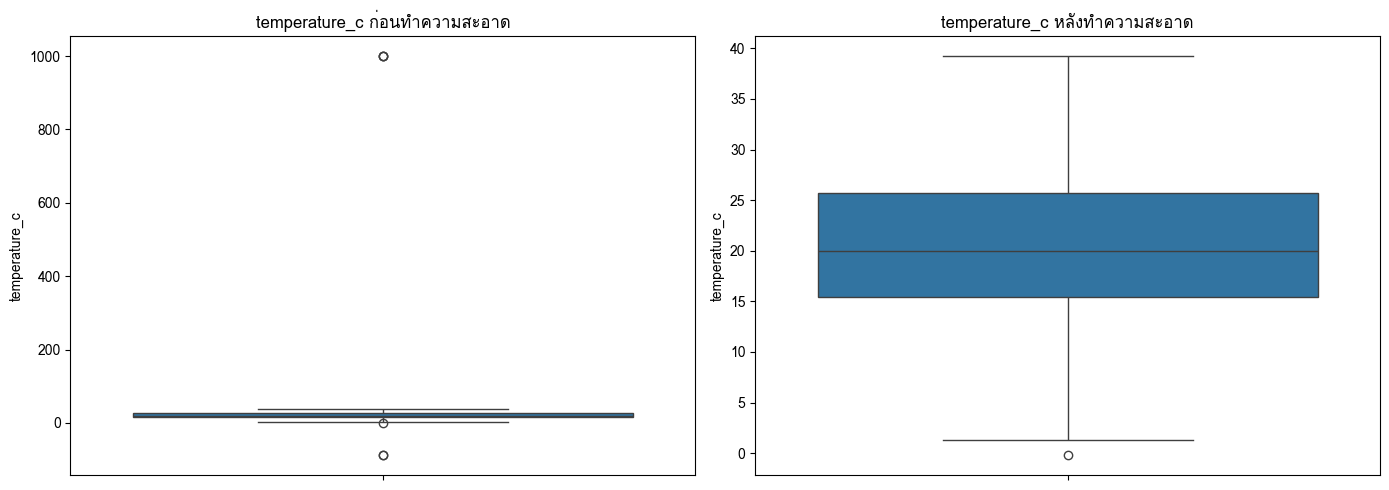

describe() ก่อนทำความสะอาด:
count    2055.000000
mean       21.837421
std        38.215806
min       -88.000000
25%        15.400000
50%        20.000000
75%        25.700000
max       999.000000
Name: temperature_c, dtype: float64

describe() หลังทำความสะอาด:
count    2050.000000
mean       20.514585
std         7.243377
min        -0.200000
25%        15.425000
50%        20.000000
75%        25.675000
max        39.200000
Name: temperature_c, dtype: float64


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, y="temperature_c", ax=axes[0])
axes[0].set_title("temperature_c ก่อนทำความสะอาด")
sns.boxplot(data=df_clean, y="temperature_c", ax=axes[1])
axes[1].set_title("temperature_c หลังทำความสะอาด")
plt.tight_layout()
plt.show()

print("describe() ก่อนทำความสะอาด:")
print(df["temperature_c"].describe())
print("\ndescribe() หลังทำความสะอาด:")
print(df_clean["temperature_c"].describe())

**🔍 สังเกต:** ค่า `std` (ส่วนเบี่ยงเบนมาตรฐาน) ของ `temperature_c` ควรลดลงอย่างชัดเจนหลังทำความสะอาด เพราะ outliers ที่รุนแรง (999, -88) ถูกลบออกไปแล้ว ทำให้ค่าทางสถิติสะท้อนความเป็นจริงของข้อมูลมากขึ้น — นี่คือเหตุผลที่ต้องจัดการ outliers ก่อนนำไปวิเคราะห์ต่อหรือสร้างโมเดล


---
# ส่วนที่ 3: Data Transformation

ตอนนี้ข้อมูลสะอาดขึ้นแล้ว (missing values จัดการแล้ว, outliers ตัดสินใจแล้ว) — ขั้นต่อไปคือ**แปลงข้อมูลให้พร้อมสำหรับการวิเคราะห์/สร้างโมเดล**

**ทำไมต้อง transform ข้อมูล?**
- คอลัมน์ตัวเลขมี**สเกลต่างกันมาก** (เช่น `pressure_hpa` อยู่ราว 1000 แต่ `rainfall_mm` อยู่ราว 0-20) — โมเดล Machine Learning หลายแบบจะให้น้ำหนักกับคอลัมน์ที่มีค่าตัวเลขใหญ่มากเกินจริง
- ข้อมูลเชิงหมวดหมู่ (categorical เช่น ชื่อเมือง, ภูมิภาค) เป็น **text** ซึ่งโมเดลคณิตศาสตร์**ไม่เข้าใจ** ต้องแปลงเป็นตัวเลขก่อน

ก่อนเริ่ม สร้าง `df_clean` ให้สมบูรณ์ (เติม missing values ที่เหลือด้วย median สำหรับตัวเลข) เพื่อให้พร้อมสำหรับขั้นตอน transform


In [41]:
# เติม missing values ที่เหลือทั้งหมดด้วย median (ใช้กลยุทธ์ที่เรียนมาจากส่วนที่ 1)
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("จำนวน missing values ที่เหลือในแต่ละคอลัมน์:")
print(df_clean[numeric_cols].isnull().sum())

จำนวน missing values ที่เหลือในแต่ละคอลัมน์:
temperature_c     0
humidity_pct      0
rainfall_mm       0
wind_speed_kmh    0
pressure_hpa      0
dtype: int64


---
## 7. Normalization (Min-Max Scaling)

**Normalization** ปรับค่าทุกค่าให้อยู่ในช่วง **0 ถึง 1** โดยรักษาสัดส่วนการกระจายตัวเดิมไว้

**สูตร:**
```
x_normalized = (x - min) / (max - min)
```

เชื่อมกับ vectorized operation ที่เรียนมาจาก NumPy — คำนวณกับทั้งคอลัมน์พร้อมกันได้เลยโดยไม่ต้องเขียน loop


In [42]:
def min_max_normalize(series):
    return (series - series.min()) / (series.max() - series.min())

df_clean["temperature_norm"] = min_max_normalize(df_clean["temperature_c"])

print("ก่อน normalize:")
print(df_clean["temperature_c"].describe()[["min", "max", "mean"]])
print("\nหลัง normalize (ควรอยู่ในช่วง 0-1):")
print(df_clean["temperature_norm"].describe()[["min", "max", "mean"]])

ก่อน normalize:
min     -0.200000
max     39.200000
mean    20.509614
Name: temperature_c, dtype: float64

หลัง normalize (ควรอยู่ในช่วง 0-1):
min     0.000000
max     1.000000
mean    0.525625
Name: temperature_norm, dtype: float64


### 7.1 Normalization ด้วย scikit-learn (`MinMaxScaler`)

ในงานจริงนิยมใช้ `MinMaxScaler` จาก scikit-learn มากกว่าเขียนสูตรเอง เพราะใช้ร่วมกับขั้นตอนสร้างโมเดลได้สะดวกกว่า (และจดจำค่า min/max ไว้ใช้กับข้อมูลใหม่ได้ในอนาคต)


In [43]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# .fit_transform() ต้องการ array 2 มิติ -- ใช้ [[ ]] เพื่อเลือกเป็น DataFrame (ไม่ใช่ Series)
df_clean["humidity_norm"] = scaler.fit_transform(df_clean[["humidity_pct"]])

print(df_clean[["humidity_pct", "humidity_norm"]].describe().loc[["min", "max"]])

     humidity_pct  humidity_norm
min          21.5            0.0
max         100.0            1.0


---
## 8. Standardization (Z-score Scaling)

**Standardization** ปรับค่าให้มี**ค่าเฉลี่ย = 0** และ**ส่วนเบี่ยงเบนมาตรฐาน = 1** — ใช้สูตรเดียวกับ Z-score ที่เรียนมาในหัวข้อ outliers!

**สูตร:**
```
x_standardized = (x - mean) / std
```

**ความแตกต่างจาก Normalization:**

| | Normalization | Standardization |
|---|---|---|
| ช่วงผลลัพธ์ | 0 ถึง 1 (ค่าคงที่) | ไม่จำกัดช่วง (ขึ้นกับข้อมูล) |
| ไวต่อ outliers | ✅ ไวมาก (min/max ถูกดึงค่าง่าย) | ระดับกลาง (mean/std ก็ถูกดึงค่าได้ แต่น้อยกว่า) |
| เหมาะกับ | ข้อมูลที่รู้ขอบเขตชัดเจน, Neural Network | ข้อมูลที่กระจายแบบ normal distribution, โมเดลเชิงเส้น |


In [44]:
def z_score_standardize(series):
    return (series - series.mean()) / series.std()

df_clean["temperature_std"] = z_score_standardize(df_clean["temperature_c"])

print("หลัง standardize (mean ควรใกล้ 0, std ควรใกล้ 1):")
print(df_clean["temperature_std"].describe()[["mean", "std"]])

หลัง standardize (mean ควรใกล้ 0, std ควรใกล้ 1):
mean    3.012083e-16
std     1.000000e+00
Name: temperature_std, dtype: float64


### 8.1 Standardization ด้วย scikit-learn (`StandardScaler`)


In [45]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()
df_clean["pressure_std"] = scaler_std.fit_transform(df_clean[["pressure_hpa"]])

print(df_clean["pressure_std"].describe()[["mean", "std"]].round(4))

mean   -0.0000
std     1.0002
Name: pressure_std, dtype: float64


### 8.2 เปรียบเทียบก่อน-หลัง Transformation ด้วยกราฟ


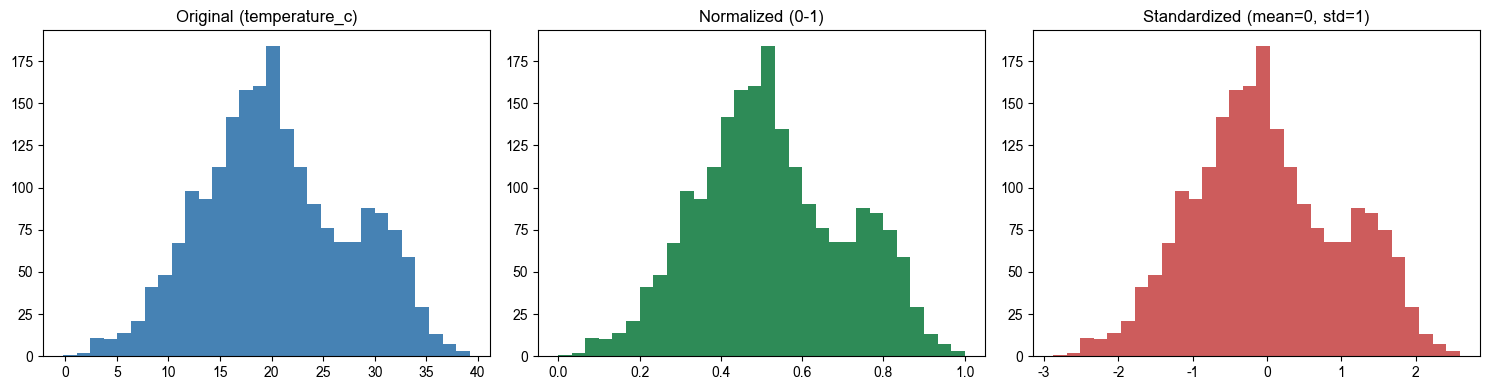

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_clean["temperature_c"], bins=30, color="steelblue")
axes[0].set_title("Original (temperature_c)")

axes[1].hist(df_clean["temperature_norm"], bins=30, color="seagreen")
axes[1].set_title("Normalized (0-1)")

axes[2].hist(df_clean["temperature_std"], bins=30, color="indianred")
axes[2].set_title("Standardized (mean=0, std=1)")

plt.tight_layout()
plt.show()

**🔍 สังเกต:** รูปทรงการกระจายตัว (shape) ของฮิสโตแกรมทั้ง 3 แบบ**เหมือนกัน** — Normalization และ Standardization แค่เปลี่ยน "สเกล" ของแกน x ไม่ได้เปลี่ยนรูปทรงการกระจายตัวของข้อมูล (นี่คือจุดสำคัญที่ต้องเข้าใจ: การ scale ไม่ใช่การเปลี่ยนแปลงลักษณะของข้อมูล แค่เปลี่ยนหน่วยวัด)


---
## 9. Encoding Categorical Data

คอลัมน์เชิงหมวดหมู่ (เช่น `region`, `city`) เป็น **text** — โมเดลคณิตศาสตร์ทำงานกับตัวเลขเท่านั้น ต้องแปลง (encode) ก่อนนำไปใช้

### 9.1 Label Encoding — แปลงแต่ละหมวดหมู่เป็นเลขจำนวนเต็ม

แปลงแต่ละค่าที่ไม่ซ้ำกันให้เป็นเลข 0, 1, 2, ... ตามลำดับ — ง่ายและประหยัดพื้นที่ แต่มีข้อเสีย: **โมเดลอาจเข้าใจผิดว่าตัวเลขมีความหมายเชิงลำดับ** (เช่น คิดว่า region รหัส 2 "มากกว่า" รหัส 1 ทั้งที่จริงเป็นแค่ชื่อ ไม่มีลำดับ)


In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_clean["region_label"] = le.fit_transform(df_clean["region"])

print(df_clean[["region", "region_label"]].drop_duplicates().sort_values("region_label"))

print("\nคลาสที่ encoder จดจำไว้ (เรียงตามรหัสที่ได้):", le.classes_)

           region  region_label
4          Africa             0
1            Asia             1
10         Europe             2
0   North America             3
5         Oceania             4
6   South America             5

คลาสที่ encoder จดจำไว้ (เรียงตามรหัสที่ได้): ['Africa' 'Asia' 'Europe' 'North America' 'Oceania' 'South America']


**⚠️ ข้อควรระวัง:** Label Encoding เหมาะกับข้อมูลที่มี**ลำดับความหมายจริง** (เรียกว่า ordinal data) เช่น ระดับการศึกษา (ประถม < มัธยม < ปริญญา) แต่**ไม่เหมาะ**กับข้อมูลที่ไม่มีลำดับ (nominal data) เช่น ชื่อภูมิภาค เพราะ "Asia"=0, "Europe"=1 ไม่ได้แปลว่า Europe "มากกว่า" Asia แต่โมเดลบางชนิดอาจตีความผิดแบบนั้น

### 9.2 One-Hot Encoding — แปลงเป็นคอลัมน์ 0/1 แยกตามหมวดหมู่

สร้างคอลัมน์ใหม่ 1 คอลัมน์ต่อหมวดหมู่ แต่ละคอลัมน์มีค่า 0 หรือ 1 (เชื่อมกับ `bool` ที่เรียนมา) — แก้ปัญหาเรื่อง "ลำดับ" ที่ Label Encoding มี เพราะไม่มีตัวเลขที่บอกลำดับเลย


In [48]:
# pd.get_dummies() คือฟังก์ชันหลักของ pandas สำหรับ One-Hot Encoding
region_onehot = pd.get_dummies(df_clean["region"], prefix="region")
print(region_onehot.head())

print("\nshape ของผลลัพธ์ one-hot (จำนวนคอลัมน์ = จำนวนหมวดหมู่ที่ไม่ซ้ำกัน):", region_onehot.shape)
print("จำนวนหมวดหมู่ของ region:", df_clean["region"].nunique())

   region_Africa  region_Asia  region_Europe  region_North America  \
0          False        False          False                  True   
1          False         True          False                 False   
2          False        False          False                  True   
3          False         True          False                 False   
4           True        False          False                 False   

   region_Oceania  region_South America  
0           False                 False  
1           False                 False  
2           False                 False  
3           False                 False  
4           False                 False  

shape ของผลลัพธ์ one-hot (จำนวนคอลัมน์ = จำนวนหมวดหมู่ที่ไม่ซ้ำกัน): (2070, 6)
จำนวนหมวดหมู่ของ region: 6


### 9.3 รวม One-Hot Encoding กลับเข้า DataFrame หลัก (เชื่อมกับ `concat()` ที่เรียนมาจาก Session 9)


In [49]:
df_with_onehot = pd.concat([df_clean, region_onehot], axis=1)   # axis=1 ต่อแนวนอน (เพิ่มคอลัมน์)
print(df_with_onehot[["city", "region"] + list(region_onehot.columns)].head())

          city         region  region_Africa  region_Asia  region_Europe  \
0     New York  North America          False        False          False   
1        Tokyo           Asia          False         True          False   
2  Los Angeles  North America          False        False          False   
3       Mumbai           Asia          False         True          False   
4    Cape Town         Africa           True        False          False   

   region_North America  region_Oceania  region_South America  
0                  True           False                 False  
1                 False           False                 False  
2                  True           False                 False  
3                 False           False                 False  
4                 False           False                 False  


### 9.4 Label Encoding vs One-Hot Encoding — สรุปเมื่อไหร่ใช้อันไหน

| | Label Encoding | One-Hot Encoding |
|---|---|---|
| จำนวนคอลัมน์ที่ได้ | 1 คอลัมน์ (แทนค่าด้วยเลข) | N คอลัมน์ (N = จำนวนหมวดหมู่) |
| เหมาะกับข้อมูล | Ordinal (มีลำดับ เช่น ระดับความพอใจ) | Nominal (ไม่มีลำดับ เช่น ชื่อเมือง, สี) |
| ข้อเสีย | โมเดลอาจเข้าใจผิดว่ามีลำดับ | ถ้าหมวดหมู่มีมาก จะได้คอลัมน์เยอะมาก (เปลือง memory) |
| ตัวอย่างที่เหมาะ | ระดับการศึกษา, ขนาดเสื้อ (S/M/L) | ภูมิภาค, ประเทศ, ชื่อเมือง |

**กรณีนี้:** `region` เป็นข้อมูลเชิงหมวดหมู่ที่**ไม่มีลำดับ** (Asia ไม่ได้ "มากกว่า/น้อยกว่า" Europe) จึง **One-Hot Encoding เหมาะกว่า** Label Encoding ในทางทฤษฎี — แต่ Label Encoding ก็ยังพบเห็นได้บ่อยในทางปฏิบัติเมื่อต้องประหยัดพื้นที่หรือใช้กับโมเดลบางประเภท (เช่น Tree-based models ที่ไม่สนใจเรื่องลำดับเชิงตัวเลข)


---
## 10. สร้าง New Feature อย่างง่าย (Feature Engineering เบื้องต้น)

**Feature Engineering** คือการสร้างคอลัมน์ใหม่จากข้อมูลที่มีอยู่ เพื่อให้ได้ข้อมูลที่มีประโยชน์มากขึ้นสำหรับการวิเคราะห์/สร้างโมเดล — เชื่อมกับ `apply()`/`lambda` ที่เรียนมาจาก Session 9

### 10.1 สร้าง Feature จากการคำนวณคอลัมน์ที่มีอยู่ (vectorized operation)


In [50]:
# Feature 1: Heat Index แบบง่าย (รวมผลของอุณหภูมิและความชื้น)
df_clean["heat_index_simple"] = df_clean["temperature_c"] + (df_clean["humidity_pct"] / 100) * 5

print(df_clean[["city", "temperature_c", "humidity_pct", "heat_index_simple"]].head())

          city  temperature_c  humidity_pct  heat_index_simple
0     New York           15.7          72.6              19.33
1        Tokyo           18.3          60.6              21.33
2  Los Angeles           20.6          46.8              22.94
3       Mumbai           31.0          73.4              34.67
4    Cape Town           19.1          55.0              21.85


### 10.2 สร้าง Feature จากวันที่ (Date Feature Extraction)

เชื่อมกับ `.dt` accessor ที่เรียนมาจาก Session 8 — ดึงส่วนประกอบของวันที่มาเป็น feature ใหม่ได้หลากหลาย


In [51]:
df_clean["month"] = df_clean["date"].dt.month
df_clean["day_of_week"] = df_clean["date"].dt.day_name()
df_clean["is_weekend"] = df_clean["date"].dt.dayofweek >= 5   # 5=เสาร์, 6=อาทิตย์ -> ได้ True/False

print(df_clean[["date", "month", "day_of_week", "is_weekend"]].head(10))

        date  month day_of_week  is_weekend
0 2025-03-24      3      Monday       False
1 2025-02-09      2      Sunday        True
2 2025-02-01      2    Saturday        True
3 2025-01-19      1      Sunday        True
4 2025-02-03      2      Monday       False
5 2025-03-18      3     Tuesday       False
6 2025-02-13      2    Thursday       False
7 2025-02-15      2    Saturday        True
8 2025-02-01      2    Saturday        True
9 2025-02-06      2    Thursday       False


### 10.3 สร้าง Feature เชิงหมวดหมู่จากตัวเลข (Binning)

แปลงตัวเลขต่อเนื่องให้เป็นกลุ่ม/หมวดหมู่ — เชื่อมกับฟังก์ชัน `def` ที่ใช้กับ `.apply()` ที่เรียนมา


In [52]:
def categorize_temperature(temp):
    if temp < 15:
        return "เย็น"
    elif temp < 25:
        return "อบอุ่น"
    elif temp < 35:
        return "ร้อน"
    else:
        return "ร้อนจัด"

df_clean["temp_category"] = df_clean["temperature_c"].apply(categorize_temperature)
print(df_clean[["city", "temperature_c", "temp_category"]].head(10))
print("\nสรุปจำนวนแต่ละหมวด:")
print(df_clean["temp_category"].value_counts())

           city  temperature_c temp_category
0      New York           15.7        อบอุ่น
1         Tokyo           18.3        อบอุ่น
2   Los Angeles           20.6        อบอุ่น
3        Mumbai           31.0          ร้อน
4     Cape Town           19.1        อบอุ่น
5      Auckland           19.7        อบอุ่น
6  Buenos Aires           22.1        อบอุ่น
7   Mexico City           19.6        อบอุ่น
8  Buenos Aires           20.8        อบอุ่น
9   Los Angeles           21.5        อบอุ่น

สรุปจำนวนแต่ละหมวด:
temp_category
อบอุ่น     1047
ร้อน        532
เย็น        465
ร้อนจัด      26
Name: count, dtype: int64


### 10.4 สร้าง Feature จากการรวมหลายคอลัมน์ (Interaction Feature)

บางครั้ง feature ที่มีประโยชน์เกิดจาก "ความสัมพันธ์ระหว่าง 2 คอลัมน์" ไม่ใช่แค่คอลัมน์เดียว


In [53]:
# Feature: อัตราส่วนฝนต่อความชื้น (สมมติว่ามีประโยชน์ในการวิเคราะห์)
df_clean["rain_humidity_ratio"] = df_clean["rainfall_mm"] / (df_clean["humidity_pct"] + 1)   # +1 ป้องกันหารด้วย 0

print(df_clean[["city", "rainfall_mm", "humidity_pct", "rain_humidity_ratio"]].head())

# Feature: ผลต่างระหว่างอุณหภูมิวันนี้กับอุณหภูมิเฉลี่ยของเมืองนั้น (เชื่อมกับ groupby + transform)
df_clean["temp_diff_from_city_avg"] = df_clean["temperature_c"] - df_clean.groupby("city")["temperature_c"].transform("mean")

print("\nผลต่างจากอุณหภูมิเฉลี่ยของเมืองนั้น:")
print(df_clean[["city", "temperature_c", "temp_diff_from_city_avg"]].head())

          city  rainfall_mm  humidity_pct  rain_humidity_ratio
0     New York          6.3          72.6             0.085598
1        Tokyo          0.0          60.6             0.000000
2  Los Angeles          1.2          46.8             0.025105
3       Mumbai          8.0          73.4             0.107527
4    Cape Town          0.0          55.0             0.000000

ผลต่างจากอุณหภูมิเฉลี่ยของเมืองนั้น:
          city  temperature_c  temp_diff_from_city_avg
0     New York           15.7                 0.223333
1        Tokyo           18.3                -0.150000
2  Los Angeles           20.6                -0.050000
3       Mumbai           31.0                 0.127778
4    Cape Town           19.1                -0.062921


> 💡 **เกร็ดเสริม:** `.transform()` คล้าย `.apply()` กับ `groupby()` แต่คืนค่าที่มีขนาดเท่ากับข้อมูลต้นฉบับเสมอ (ไม่ยุบรวมเป็นค่าเดียวต่อกลุ่มแบบ `.agg()`) ทำให้เอาไปคำนวณต่อกับคอลัมน์เดิมได้ทันทีแบบในตัวอย่างนี้

### 10.5 สรุปภาพรวม: ตาราง Feature ใหม่ที่สร้างขึ้นทั้งหมด


In [54]:
new_features = ["heat_index_simple", "month", "day_of_week", "is_weekend",
                 "temp_category", "rain_humidity_ratio", "temp_diff_from_city_avg"]
print(df_clean[["city", "date"] + new_features].head())

          city       date  heat_index_simple  month day_of_week  is_weekend  \
0     New York 2025-03-24              19.33      3      Monday       False   
1        Tokyo 2025-02-09              21.33      2      Sunday        True   
2  Los Angeles 2025-02-01              22.94      2    Saturday        True   
3       Mumbai 2025-01-19              34.67      1      Sunday        True   
4    Cape Town 2025-02-03              21.85      2      Monday       False   

  temp_category  rain_humidity_ratio  temp_diff_from_city_avg  
0        อบอุ่น             0.085598                 0.223333  
1        อบอุ่น             0.000000                -0.150000  
2        อบอุ่น             0.025105                -0.050000  
3          ร้อน             0.107527                 0.127778  
4        อบอุ่น             0.000000                -0.062921  


---
## 🧪 แบบฝึกหัดท้ายเรื่อง

> ลองทำเองในเซลล์ที่เตรียมไว้ด้านล่างแต่ละข้อ ไม่มีเฉลยให้ — ถ้าไม่แน่ใจให้ลองรันดูผลลัพธ์ หรือถามอาจารย์/เพื่อนได้เลย ใช้ไฟล์ `world_weather_sample.csv`

### ข้อ 1: ตรวจหาและจัดการ Missing Values
1. โหลดข้อมูลใหม่ (ตัวแปรชื่อ `df_ex`) แล้วตรวจสอบ missing values ด้วย `.isnull().sum()`
2. วาด heatmap ของ missing values
3. เลือกกลยุทธ์ fill ให้กับคอลัมน์ `rainfall_mm` (mean, median, หรือ 0) **พร้อมเขียนเหตุผล**เป็นคอมเมนต์ว่าทำไมเลือกวิธีนี้


In [55]:
# เขียนคำตอบข้อ 1 ที่นี่
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# โหลดข้อมูล
df_ex = pd.read_csv("world_weather_sample.csv")

# ตรวจสอบ Missing Values
print(df_ex.isnull().sum())

# Heatmap ของ Missing Values
plt.figure(figsize=(8,5))
sns.heatmap(df_ex.isnull(), cbar=False, cmap="viridis")
plt.show()

# เติมค่า Missing ในคอลัมน์ rainfall_mm ด้วยค่าเฉลี่ย
df_ex["rainfall_mm"] = df_ex["rainfall_mm"].fillna(df_ex["rainfall_mm"].mean())

# ตรวจสอบอีกครั้ง
print(df_ex.isnull().sum())

FileNotFoundError: [Errno 2] No such file or directory: 'world_weather_sample.csv'

### ข้อ 2: ตรวจหา Outliers
1. ใช้ฟังก์ชัน `detect_outliers_iqr()` ที่เรียนมา ตรวจหา outliers ในคอลัมน์ `pressure_hpa`
2. วาด boxplot ของ `pressure_hpa`
3. ตัดสินใจว่าจะ keep/remove/cap กับ outliers ที่เจอ **พร้อมเขียนเหตุผล**


In [ ]:
# เขียนคำตอบข้อ 2 ที่นี่


### ข้อ 3: Normalization และ Standardization
1. ทำ Min-Max Normalization กับคอลัมน์ `wind_speed_kmh` (เขียนสูตรเองหรือใช้ `MinMaxScaler` ก็ได้)
2. ทำ Standardization กับคอลัมน์เดียวกัน
3. วาดฮิสโตแกรมเทียบกัน 3 แบบ (original, normalized, standardized) เหมือนตัวอย่างที่เรียนมา


In [ ]:
# เขียนคำตอบข้อ 3 ที่นี่


### ข้อ 4: Encoding Categorical
1. ทำ Label Encoding กับคอลัมน์ `city` แล้วดูว่าได้รหัสอะไรบ้าง
2. ทำ One-Hot Encoding กับคอลัมน์ `city` ด้วย `pd.get_dummies()` แล้วดู shape ของผลลัพธ์
3. อธิบายเป็นคอมเมนต์ว่าในกรณีนี้ ควรใช้ Label หรือ One-Hot Encoding มากกว่า เพราะอะไร


In [ ]:
# เขียนคำตอบข้อ 4 ที่นี่


### ข้อ 5: สร้าง New Feature
1. สร้าง feature ใหม่ชื่อ `wind_chill_simple` จากการคำนวณ `temperature_c - (wind_speed_kmh * 0.1)` (จำลองความรู้สึกหนาวจากลม)
2. สร้าง feature เชิงหมวดหมู่ `rain_level` จาก `rainfall_mm`: 0 = "ไม่มีฝน", 0-5 = "ฝนน้อย", 5-15 = "ฝนปานกลาง", มากกว่า 15 = "ฝนมาก" (ใช้ `def` + `.apply()`)
3. สร้าง feature `is_extreme_weather` (True/False) ที่เป็น True เมื่ออุณหภูมิสูงกว่า 35 องศา **หรือ** ฝนตกมากกว่า 20 มม. (ใช้ `apply(axis=1)` หรือ vectorized operation ก็ได้)


In [ ]:
# เขียนคำตอบข้อ 5 ที่นี่


### ข้อ 6: ท้าทายเพิ่มเติม (Challenge) — Pipeline ทำความสะอาดข้อมูลแบบครบวงจร
จงเขียนโค้ดที่รวมทุกขั้นตอนเข้าด้วยกันเป็นลำดับ:
1. โหลดข้อมูล `world_weather_sample.csv` ใหม่
2. ตรวจสอบและรายงานสรุป missing values ทุกคอลัมน์
3. Fill missing values ด้วยกลยุทธ์ที่เหมาะสมที่สุดสำหรับแต่ละคอลัมน์ (อ้างอิงตารางสรุปที่เรียนมา)
4. ตรวจหาและจัดการ outliers ในคอลัมน์ `temperature_c`, `humidity_pct`, `wind_speed_kmh` ด้วยวิธีที่เหมาะสม (remove หรือ cap)
5. ทำ Standardization กับคอลัมน์ตัวเลขทั้งหมด
6. ทำ One-Hot Encoding กับคอลัมน์ `region`
7. สร้าง feature ใหม่อย่างน้อย 2 อย่าง
8. แสดงผลลัพธ์สุดท้ายด้วย `.info()` และ `.head()`


In [ ]:
# เขียนคำตอบข้อ 6 ที่นี่


---
## 🔗 เชื่อม Colab กับ GitHub

เก็บ Notebook นี้ขึ้น GitHub ต่อจากไฟล์ก่อนหน้า

### วิธีที่ 1: เซฟจาก Colab ขึ้น GitHub ตรงๆ (สำหรับ Notebook)

1. ใน Colab ไปที่เมนู **File → Save a copy in GitHub**
2. เลือก repository เดิมที่ใช้เก็บ Notebook คาบก่อนๆ (เช่น `SC612104-coursework`)
3. ตั้งชื่อไฟล์และ commit message (เช่น `"เพิ่ม notebook: data cleaning (missing/outliers/transformation)"`) แล้วกด **OK**

### วิธีที่ 2: ใช้ Git ผ่าน Terminal

```bash
git clone https://github.com/<username>/<repo-name>.git
cd <repo-name>
git add notebook.ipynb
git commit -m "เพิ่ม notebook: data cleaning"
git push origin main
```

> 💡 **Tip:** Data Cleaning คือขั้นตอนที่ใช้เวลามากที่สุดในงาน Data Science จริง (มักกินเวลา 60-80% ของทั้งโปรเจกต์อย่างที่เคยพูดถึงในคาบต้นๆ) — ทักษะที่เรียนในไฟล์นี้ (ตรวจหา missing/outliers, เลือกกลยุทธ์อย่างมีเหตุผล, transform ข้อมูล) คือพื้นฐานสำคัญที่สุดก่อนนำข้อมูลไปสร้างโมเดล
